# Structural Simplicity in Popular Music

## Introduction
Popular music is often shaped by a balance between artistic expression and commercial success. Songs can differ a lot in genre, style, structure, and lyrics, but many people believe that the most successful songs tend to follow certain patterns that make them easier for large audiences to enjoy. One common idea is that popular songs have become shorter, simpler, and more repetitive over time. This project explores that idea by examining whether commercially successful songs show measurable signs of structural simplicity compared to non-charting songs.

The starting point for this project was a simple comment made by my father: that many modern popular songs sound “dumb and repetitive.” Although informal, this reflects a wider criticism of contemporary popular music. Instead of treating this only as a personal opinion, the project turns it into a research question that can be tested with data.

To investigate this, the project focuses on three measurable aspects of structural simplicity. The first is song duration, based on the idea that shorter songs may be better at keeping attention and encouraging replay. 
The second is lyrical repetition, since repeated words and phrases can make songs easier to remember.
The third is lexical diversity, which measures how varied a song’s vocabulary is. 
A lower level of lexical diversity may suggest simpler lyrics with more repeated words and a smaller vocabulary. 
Together, these measures help turn the broad idea of “simplicity” into something that can be tested and analyzed.

## Hypotheses
This project examines whether commercially successful songs are structurally simpler than non-charting songs. In this context, structural simplicity is measured through three main features: song duration, lyrical repetition, and lexical diversity.

The hypotheses of the project are:
- $H0_1$: There is no difference in average song duration between Billboard-charting songs and non-charting Spotify songs.
- $H1_1$: Billboard-charting songs are shorter on average than non-charting Spotify songs.

- $H0_2$: There is no difference in lyrical repetition between Billboard-charting songs and non-charting Spotify songs.
- $H1_2$: Billboard-charting songs are more repetitive than non-charting Spotify songs.

- $H0_3$: There is no difference in lexical diversity between Billboard-charting songs and non-charting Spotify songs. 
- $H1_3$: Billboard-charting songs have lower lexical diversity than non-charting Spotify songs.

- $H0_4$: Song duration, lyrical repetition, and lexical diversity are not associated with chart success.
- $H1_4$: Shorter duration, higher lyrical repetition, and lower lexical diversity are associated with chart success.

## Related Work
The relationship between simplicity and popularity in music has been explored in several previous studies. For example, Parada-Cabaleiro (2024) analyzed over 350,000 English song lyrics from 1970 to 2020 and found that lyrics have generally become simpler over time in terms of vocabulary richness, readability, and repetition [Parada-Cabaleiro et al., 2024]. Their work demonstrates that large-scale text analysis can reveal clear structural trends in music. However, their study focuses primarily on historical evolution rather than directly comparing successful and non-successful songs.

Similarly, Varnum (2021) examined lyrical simplicity in American popular music across multiple decades and found a consistent trend toward simpler and more repetitive lyrics [Varnum, 2021]. Their findings support the broader idea that simplicity may be linked to mass appeal. However, like many studies in this area, their analysis is limited to songs that are already considered popular, without comparing them to a wider population of non-charting music.

This project builds on these findings but takes a different approach. Instead of focusing only on trends over time or analyzing already successful songs, it directly compares Billboard-charting songs with non-charting Spotify songs. By combining two independent datasets and introducing measurable features such as song duration, repetition score, and lexical diversity, this project provides a more direct test of whether commercially successful songs are structurally simpler than the broader population of songs.


## Data

This project uses two main independent data sources. The first is a Spotify songs dataset containing track metadata, audio features, lyrics, duration, and language labels. This is the main analytical dataset because it provides the information needed to measure song length, lyrical repetition, and lexical diversity. The second is a Billboard Hot 100 dataset, which is used to represent commercial success through chart appearance and chart-performance indicators.

The Spotify dataset, `spotify_songs.csv`, contains 18,454 songs and 25 variables. It includes information such as track name, artist, lyrics, popularity, album details, duration, and audio features. Since the main research question focuses on structural simplicity, this dataset is especially important because it provides the lyrical content needed for text-based analysis.

The Billboard dataset, `charts.csv`, contains 330,087 weekly chart observations and 7 variables. Unlike the Spotify data, it does not contain lyrics or audio features, but it provides a direct measure of commercial success. Because the data is recorded at the weekly chart-entry level, it was later aggregated to the song level so that each song could be matched with a single summary record.

Before the analysis, several preprocessing steps were applied. First, the Spotify dataset was restricted to English-language songs with available lyrics, since the project does not attempt multilingual lyric analysis. Second, duplicate Spotify entries were removed, as many songs appeared multiple times due to being included in different playlists. Deduplication was performed at the track_name and track_artist level. After this cleaning step, 13,734 unique song-artist observations remained

To connect the two datasets, song and artist names were normalized in both sources. This helped reduce mismatches caused by punctuation, capitalization, bracketed text, and featured-artist notation such as “feat.” or “ft.” The Billboard data was then aggregated to the song level, producing chart-related indicators such as peak rank, weeks on board, chart entries, and average weekly rank.

The final prepared dataset, saved as `spotify_billboard_prepared.csv`, contains 13,734 observations. Among these, 3,063 songs were matched to Billboard records and classified as charting songs, while the rest were treated as non-charting songs. This merged dataset serves as the basis for the next stage of the project, where variables for duration, repetition, and lexical diversity are used to test the hypotheses.

## Methodology

// To do

## Analysis 

In [173]:
# Imports
import pandas as pd
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [174]:
# Load the data 
music_data = pd.read_csv('spotify_billboard_prepared.csv')
# a copy for the analysis work
analysis_data = music_data.copy()

In [175]:
print("Shape", analysis_data.shape)
analysis_data.head()

Shape (13734, 35)


,track_id,track_name,track_artist,lyrics,track_popularity,track_album_id,track_album_name,track_album_release_date,danceability,energy,...,best_weekly_rank,avg_weekly_rank,peak_rank,weeks_on_board,first_chart_date,last_chart_date,chart_entries,song_norm,artist_norm,is_charting
0,004s3t0ONYlzxII9PLgU6z,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,3z04Lb9Dsilqw68SHt6jLB,Love & Loss,2017-11-21,0.303,0.880,...,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0
1,00chLpzhgVjxs1zKC9UScL,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",0,6oZ6brjB8x3GoeSYdwJdPc,Gold,2005-01-01,0.845,0.652,...,3.0,24.409091,3.0,22.0,1990-04-07,1990-09-01,22.0,poison,bell biv devoe,1
2,00cqd6ZsSkLZqGMlQCR0Zo,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,41,3ssspRe42CXkhPxdc12xcp,CeeLo's Magic Moment,2012-10-29,0.425,0.378,...,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0
3,00emjlCv9azBN0fzuuyLqy,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,65,7h5X3xhh3peIK9Y0qI5hbK,KARD 2nd Digital Single ‘Dumb Litty’,2019-09-22,0.760,0.887,...,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0
4,00f9VGHfQhAHMCQ2bSjg3D,Soldier,James TW,"Hold your breath, don't look down, keep trying...",70,3GNzXsFbzdwM0WKCZtgeNP,Chapters,2019-04-26,0.496,0.639,...,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0


### We have the following columns in our dataset:
- `track_id` - the unique Spotify identifier for each track.
- `track_name` - the song title
- `track_artist` - the name namme of the main artist of the song
- `track_album_id`, `track_album_name`, and `track_album_release_date` describe the album associated with the song.
- `track_popularity` is Spotify’s popularity score for the track.
- `lyrics` ccontains the song lyrics, which are used later to measure repetition and lexical diversity.
- `language` indicates the detected language of the lyrics. In this project, only English-language songs with available lyrics were retained for analysis.
- THe dataset also includes several Spotify audio descriptors which describe musical and acoustic properties of each track.
- `track_name_norm` and `track_artist_norm` are normalized versions of the Spotify song and artist names used for matching with Billboard data.
- `song_norm` and `artist_norm` are the normalized Billboard versions of those names.
- `best_weekly_rank`
- `avg_weekly_rank`
- `peak_rank`
- `weeks_on_board`
- `first_chart_date` and `last_chart_date` indicate the time span of chart presence
- `chart_entries` counts the total number of chart appearances 
- `is_charting` the main binary success indicator used in the analysis. A value of 1 means that the song was successfully matched to Billboard and appeared on the chart at least once, while a value of 0 means that the song is treated as non-charting in the final dataset. 


In [176]:
# We convert the duration from milliseconds to minutes 
analysis_data["duration_min"] = analysis_data["duration_ms"] / 60000

In [177]:
analysis_data[analysis_data["lyrics"].str.contains(r"\bLyrics\b", case=False, na=False)]


,track_id,track_name,track_artist,lyrics,track_popularity,track_album_id,track_album_name,track_album_release_date,danceability,energy,...,avg_weekly_rank,peak_rank,weeks_on_board,first_chart_date,last_chart_date,chart_entries,song_norm,artist_norm,is_charting,duration_min
20,00ReeHCY0FQUyuAUyPJdnk,Ain't No Future In Yo' Frontin',MC Breed,Intro : (Flavor Flav) To the beat Ya'll Ah yea...,48,7mLks5uEIPmT0056mb5oV3,MC Breed & DFC,1991-01-01,0.672,0.761,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,4.078883
270,09EwNbGvUyu7BDEYG0cJro,Can't C Me,2Pac,The blind stares of a million pairs of eyes Lo...,65,4CzT5ueFBRpbILw34HQYxi,All Eyez On Me,1996-02-13,0.797,0.852,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,5.512667
455,0CJmYEsImHZ42f7W6ntlX2,Hands In The Air,8Ball,Okay; comin' from the top of my Dome when I'm ...,47,1cInbcKRuvIvW8pj9daIJU,2 Fast 2 Furious (Soundtrack),2003-01-01,0.751,0.862,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,4.205117
469,0CPnwugq0UbmaT19wAbhk8,Love,The Globetroddas,C'mon Dedicate this record to you and yours Al...,0,02B3esbd2kGEp3E99QA9G6,The Love EP,2013-03-01,0.890,0.644,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,4.545300
579,0eKRwDBVWxCXWpLYFYrbd1,Your Silent Face - 2015 Remaster,New Order,A thought that never changes remains a stupid ...,54,6NTrwu1XJ56jBPx7HMksbZ,Power Corruption and Lies,1983-05-02,0.642,0.778,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,5.993117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13185,7Je4aDuchYqv2YWMudH5ZM,Door #1,LSG,LSG Lyrics Door #1 1 - What's behind door numb...,40,3BrZT0UzGMi2qhI5WExT8Y,Levert.Sweat.Gill,1997-10-31,0.796,0.434,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,5.026667
13242,7knYmZG6hwaxPiM2EWolTg,Past Adventures,Brendon Moeller,Lyrics for this song have yet to be released. ...,37,1eYCpCcVsvVoIZgZ2XyBnV,Fallen Angels,2019-02-22,0.693,0.851,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,5.705650
13431,7p0nLpkKaAeebJ1SIP46HM,Hollow (feat. Sabelle),My Buddy Mike,Https://lyricstranslate.com/en/major-lazer-hol...,43,0bpTeC9NXm7FDTkBgif8V2,Hollow (feat. Sabelle),2018-03-09,0.688,0.661,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,3.882283
13493,7r2VuLH3NqOu0bXF976eFY,Hit The Flow,Landis,Lyrics for this song have yet to be released. ...,57,07DbcsYT5JDCL6LVV6sYQh,Hit The Flow,2019-10-03,0.817,0.987,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0,2.531250


In [178]:
# Basic lyric cleaning and tokenization
def tokenize_lyrics(text):
    if pd.isna(text):
        return []
    
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)   #
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens = text.split()
    return tokens


In [179]:
analysis_data["lyrics"].sample(5)

3350     If you're looking for a diamond You gotta sift...
6993     Mustard on the beat, ho My bitch go loco (Go l...
11509    When the puzzle connects It's like you never f...
1219     Hahah, say Jim It's the champagne pourin', big...
5636     NA Ayy, y'all ain't never been to a party befo...
Name: lyrics, dtype: str

In [180]:
# Lets handle the placeholder lyrics
placeholder = "Lyrics for this song have yet to be released."

analysis_data["lyrics"].str.contains(placeholder, case=False, na=False).sum()


np.int64(52)

A total of 52 songs contained the placeholder text "Lyrics for this song have yet to be released."

In [181]:
# We can either drop these rows or set the lyrics to an empty string. Here, we choose to set them to an empty string.
mask = analysis_data["lyrics"].str.contains(placeholder, case=False, na=False)
analysis_data.loc[mask, "lyrics"] = ""

In [182]:
analysis_data["lyrics"].sample(5).apply(tokenize_lyrics)

9446     [joromi, joromi, i, want, you, to, love, me, j...
12105    [waking, up, knowing, there, s, a, reason, all...
2658     [wheezy, outta, here, rose, gold, seats, on, a...
4368     [you, said, you, didn, t, need, her, you, told...
8232     [oh, i, i, just, died, in, your, arms, tonight...
Name: lyrics, dtype: object

In [183]:
analysis_data["tokens"] = analysis_data["lyrics"].apply(tokenize_lyrics)

analysis_data["token_count"] = analysis_data["tokens"].apply(len)
analysis_data["unique_token_count"] = analysis_data["tokens"].apply(lambda x: len(set(x)))

In [184]:
print(analysis_data[["tokens", "token_count", "unique_token_count"]].head())

                                              tokens  token_count  \
0  [the, trees, are, singing, in, the, wind, the,...          110   
1  [na, yeah, spyderman, and, freeze, in, full, e...          462   
2  [i, really, can, t, stay, baby, it, s, cold, o...          372   
3  [get, up, out, of, my, business, you, don, t, ...          213   
4  [hold, your, breath, don, t, look, down, keep,...          398   

   unique_token_count  
0                  62  
1                 193  
2                 173  
3                  60  
4                 135  


**Lexical diversity**
This is the share of the unique word in the lyrics 
We'll do this with the following formula
$$Lexical\ diversity = \frac{\text{unique words}}{\text{total words}}$$

So if a song has:
- 100 total words
- 40 unique words

We have: 
- $\frac{40}{100} = 0.40$
That means 40% of the words are unique, which suggests less repetition than a song with a lower value.

In [185]:
analysis_data["lexical_diversity"] = np.where(
    analysis_data["token_count"] > 0,
    analysis_data["unique_token_count"] / analysis_data["token_count"],
    np.nan
)

print(analysis_data["lexical_diversity"].head())

0    0.563636
1    0.417749
2    0.465054
3    0.281690
4    0.339196
Name: lexical_diversity, dtype: float64


**Repetition Score:**
To measure lyrical repetition, we'll use the epetition score based on repeated word occurrences in each song's lyrics. After tokenizing the lyrics into individual words, the frequency of each word is counted.

$$\text{Repetition Score} = \frac{\sum_{i} \max(c_{i} - 1, 0)}{N}$$

The numerator counts how many word occurrences are repeated beyond their first appearance, while the denominator is the total number of words in the song.

For example, suppose a lyric consists of the following 6 tokens:

love love love you you me

Then:
- love appears 3 times, so it contributes 3 - 1 = 2
- you appears 2 times, so it contributes 2 - 1 = 1
- me appears 1 time, so it contributes 0
The total repeated words are therefore 2 + 1 = 3, and the repetition score is:
$$\frac{3}{6} = 0.50$$

In [186]:
analysis_data["repetition_score"] = analysis_data["tokens"].apply(
    lambda tokens: np.nan if len(tokens) == 0
    else sum(count - 1 for count in Counter(tokens).values() if count > 1) / len(tokens)
)
print(analysis_data["repetition_score"].head())

0    0.436364
1    0.582251
2    0.534946
3    0.718310
4    0.660804
Name: repetition_score, dtype: float64


In [187]:
analysis_data[[
    "track_name",
    "track_artist",
    "is_charting",
    "duration_min",
    "token_count",
    "unique_token_count",
    "lexical_diversity",
    "repetition_score"
]].head()

,track_name,track_artist,is_charting,duration_min,token_count,unique_token_count,lexical_diversity,repetition_score
0,I Feel Alive,Steady Rollin,0,6.225200,110,62,0.563636,0.436364
1,Poison,Bell Biv DeVoe,1,4.374450,462,193,0.417749,0.582251
2,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,0,4.051117,372,173,0.465054,0.534946
3,Dumb Litty,KARD,0,3.219333,213,60,0.281690,0.718310
4,Soldier,James TW,0,3.745333,398,135,0.339196,0.660804


In [188]:
analysis_data[[
    "duration_min",
    "token_count",
    "unique_token_count",
    "lexical_diversity",
    "repetition_score"
]].describe()

,duration_min,token_count,unique_token_count,lexical_diversity,repetition_score
count,13734.000000,13734.000000,13734.000000,13682.000000,13682.000000
mean,3.864153,441.407165,117.095893,0.308435,0.691565
std,0.956367,358.392781,70.843528,0.125457,0.125457
min,0.627333,0.000000,0.000000,0.006944,0.000000
25%,3.238062,241.000000,74.000000,0.228192,0.618459
50%,3.716667,349.000000,98.000000,0.302811,0.697189
75%,4.336663,532.000000,138.000000,0.381541,0.771808
max,8.618750,5705.000000,604.000000,1.000000,0.993056


In [189]:
analysis_data.groupby("is_charting")[[
    "duration_min",
    "token_count",
    "unique_token_count",
    "lexical_diversity",
    "repetition_score"
]].mean()


,duration_min,token_count,unique_token_count,lexical_diversity,repetition_score
is_charting,,,,,
0,3.816951,395.296973,112.836192,0.318086,0.681914
1,4.028596,602.047666,131.936010,0.274979,0.725021


The descriptive statistics provide an initial overview of the main variables before comparing charting and non-charting songs in more detail.

For lyrical structure, charting songs have a higher average repetition score, 0.725 compared to 0.682 for non-charting songs. This supports $H1_2$, suggesting that charting songs contain more repeated word occurrences on average.

Charting songs also have lower average lexical diversity, 0.275 compared to 0.318 for non-charting songs. This supports $H1_3$, suggesting that charting songs use a smaller share of unique words and may be lyrically simpler.

Overall, the early descriptive results partially support the structural simplification hypothesis. The lyrical measures support the idea that charting songs are simpler and more repetitive, but the duration result does not support the expectation that commercially successful songs are shorter.

In [190]:
# Check missing values in the main analysis variables
analysis_data[[
    "duration_min",
    "token_count",
    "unique_token_count",
    "lexical_diversity",
    "repetition_score",
    "is_charting",
]].isna().sum()


duration_min           0
token_count            0
unique_token_count     0
lexical_diversity     52
repetition_score      52
is_charting            0
dtype: int64

In [191]:
analysis_data[analysis_data["token_count"] == 0][[
    "track_name", "track_artist", "lyrics", "token_count"
]].head(10)


,track_name,track_artist,lyrics,token_count
1083,Never Forget - Nicky Romero Edit,Trilane,,0
1247,Break of Dawn - Duke & Jones Remix,Yellow Claw,,0
1905,Fkn Face,The Bloody Beetroots,,0
1919,Vultures,Bokassa,,0
2234,Clarity,Model Man,,0
2352,Dime (feat. Reik),Noel Schajris,,0
2596,Don't Say A Word,Sam Feldt,,0
3058,Definition of House Music,The Bloody Beetroots,,0
3110,Stories of a Ghetto Kitty,Chinese Kitty,,0
3150,Lento,Nio Garcia,,0


In [192]:
analysis_data.groupby("is_charting")[[
    "duration_min",
    "token_count",
    "unique_token_count",
    "lexical_diversity",
    "repetition_score"
]].agg(["mean", "median", "std", "min", "max"])

duration_min                                         token_count  \
                    mean    median       std       min       max        mean   
is_charting                                                                    
0               3.816951  3.648100  0.974212  0.627333  8.618750  395.296973   
1               4.028596  3.925117  0.871820  1.230217  8.614883  602.047666   

                                          ... lexical_diversity            \
            median         std min   max  ...              mean    median   
is_charting                               ...                               
0            329.0  280.871948   0  5312  ...          0.318086  0.309959   
1            444.0  517.639315  10  5705  ...          0.274979  0.277592   

                                          repetition_score            \
                  std       min       max             mean    median   
is_charting                                                            
0            0.126898  0.010352  1.000000         0.681914  0.690041   
1            0.114195  0.006944  0.701493         0.725021  0.722408   

                                           
                  std       min       max  
is_charting                                
0            0.126898  0.000000  0.989648  
1            0.114195  0.298507  0.993056  

[2 rows x 25 columns]

The grouped descriptive statistics provide a more detailed comparison between charting and non-charting songs. Charting songs have a higher mean duration of 4.03 minutes compared to 3.82 minutes for non-charting songs. The median shows the same pattern, with charting songs at 3.93 minutes and non-charting songs at 3.65 minutes. This does not support $H1_1$, because charting songs in this dataset appear slightly longer rather than shorter.

The lyrical measures show a clearer pattern. Charting songs have a much higher average token count, with around 602 words compared to 395 words for non-charting songs. They also have a higher median token count, which suggests that this difference is not only caused by a few extreme songs.

For lexical diversity, charting songs have a lower mean value of 0.275 compared to 0.318 for non-charting songs. This supports $H_{1,3}$, because charting songs use a smaller proportion of unique words. The repetition score shows the opposite pattern, with charting songs having a higher mean repetition score of 0.725 compared to 0.682 for non-charting songs. This supports $H1_2$.

Overall, the table suggests that charting songs are not shorter, but they do appear to be lyrically simpler: they contain more words, repeat words more often, and have lower lexical diversity.

In [193]:
plot_data = analysis_data.copy()
plot_data["charting_label"] = plot_data["is_charting"].map({
    0: "Non-charting",
    1: "Charting"
})

In [194]:
sns.set_theme(style="whitegrid", context="notebook")

chart_colors = {
    "Non-charting": "#C44E52",  
    "Charting": "#4C72B0"
}

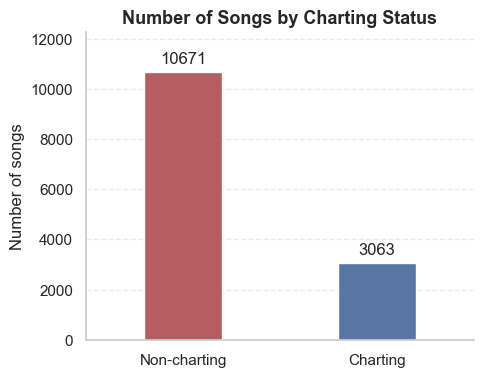

In [195]:
chart_counts = plot_data["charting_label"].value_counts().reset_index()
chart_counts.columns = ["charting_label", "count"]

plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=chart_counts,
    x="charting_label",
    y="count",
    hue="charting_label",
    palette=chart_colors,
    width=0.4,
    legend=False
)

ax.bar_label(ax.containers[0], fmt="%.0f", padding=4)
ax.bar_label(ax.containers[1], fmt="%.0f", padding=4)

plt.title("Number of Songs by Charting Status", fontsize=13, weight="bold")
plt.xlabel("")
plt.ylabel("Number of songs")
plt.ylim(0, chart_counts["count"].max() * 1.15)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.grid(axis="x", visible=False)
sns.despine()

plt.show()


### Number of Songs by Charting Status
The dataset is imbalanced, with 10,671 non-charting songs and 3,063 charting songs. This means that approximately 22% of the songs in the dataset have appeared on the Billboard chart.

This imbalance should be considered when interpreting the results, as the two groups differ substantially in size.

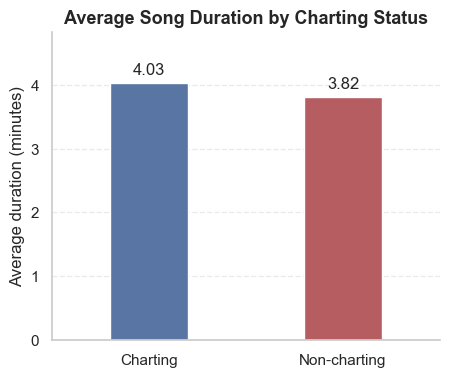

In [196]:
duration_means = plot_data.groupby("charting_label")["duration_min"].mean().reset_index()

plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=duration_means,
    x="charting_label",
    y="duration_min",
    hue="charting_label",
    palette=chart_colors,
    width=0.4,
    legend=False
)

ax.bar_label(ax.containers[0], fmt="%.2f", padding=4)
ax.bar_label(ax.containers[1], fmt="%.2f", padding=4)

plt.title("Average Song Duration by Charting Status", fontsize=13, weight="bold")
plt.xlabel("")
plt.ylabel("Average duration (minutes)")
plt.ylim(0, duration_means["duration_min"].max() * 1.2)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.grid(axis="x", visible=False)
sns.despine()

plt.show()

### Average Song Duration by Charting Status
Charting songs have a slightly higher average duration of 4.03 minutes compared to 3.82 minutes for non-charting songs. This does not support $H1_1$, since charting songs are not shorter on average. The difference is small, so statistical testing is needed before drawing a stronger conclusion.

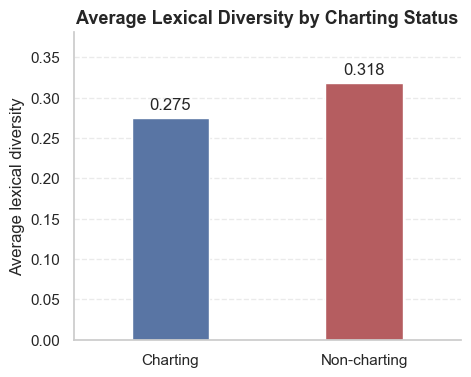

In [197]:
lexical_means = plot_data.groupby("charting_label")["lexical_diversity"].mean().reset_index()

plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=lexical_means,
    x="charting_label",
    y="lexical_diversity",
    hue="charting_label",
    palette=chart_colors,
    width=0.4,
    legend=False
)

ax.bar_label(ax.containers[0], fmt="%.3f", padding=4)
ax.bar_label(ax.containers[1], fmt="%.3f", padding=4)

plt.title("Average Lexical Diversity by Charting Status", fontsize=13, weight="bold")
plt.xlabel("")
plt.ylabel("Average lexical diversity")
plt.ylim(0, lexical_means["lexical_diversity"].max() * 1.2)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.grid(axis="x", visible=False)
sns.despine()

plt.show()

### Average Lexical Diversity by Charting Status

Charting songs have lower average lexical diversity than non-charting songs, 0.275 compared to 0.318. This supports $H1_3$, suggesting that charting songs use a smaller share of unique words and may be lyrically simpler.

This difference appears stronger than the duration difference, indicating that lyrical structure may be more relevant than song length in this analysis.

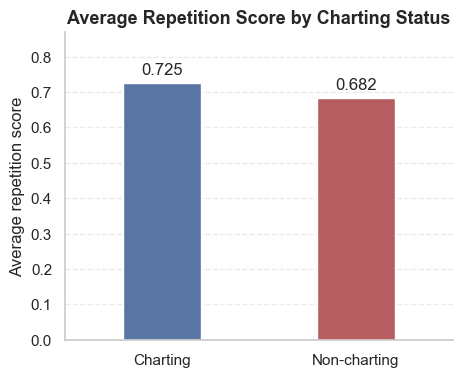

In [198]:
repetition_means = plot_data.groupby("charting_label")["repetition_score"].mean().reset_index()

plt.figure(figsize=(5, 4))

ax = sns.barplot(
    data=repetition_means,
    x="charting_label",
    y="repetition_score",
    hue="charting_label",
    palette=chart_colors,
    width=0.4,
    legend=False
)

ax.bar_label(ax.containers[0], fmt="%.3f", padding=4)
ax.bar_label(ax.containers[1], fmt="%.3f", padding=4)

plt.title("Average Repetition Score by Charting Status", fontsize=13, weight="bold")
plt.xlabel("")
plt.ylabel("Average repetition score")
plt.ylim(0, repetition_means["repetition_score"].max() * 1.2)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.grid(axis="x", visible=False)
sns.despine()

plt.show()

### Average Repetition Score by Charting Status

Charting songs have a higher average repetition score than non-charting songs, 0.725 compared to 0.682. This supports $H1_2$, suggesting that charting songs repeat words more often.

Together with the lexical diversity result, this provides consistent evidence that charting songs may rely more on simpler and more repetitive lyrical structures.

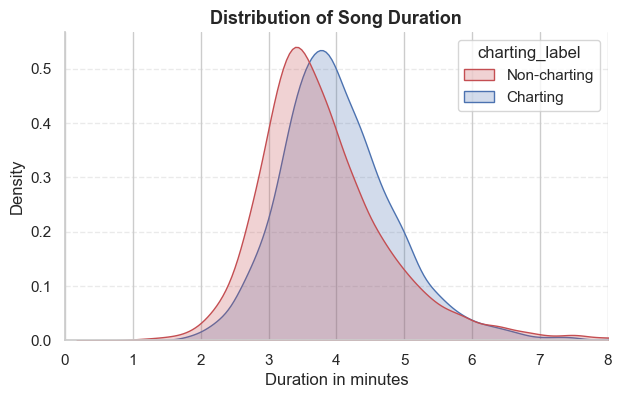

In [199]:
plt.figure(figsize=(7, 4))

sns.kdeplot(
    data=plot_data,
    x="duration_min",
    hue="charting_label",
    fill=True,
    alpha=0.25,
    palette=chart_colors,
    common_norm=False
)

plt.title("Distribution of Song Duration", fontsize=13, weight="bold")
plt.xlabel("Duration in minutes")
plt.ylabel("Density")
plt.xlim(0, 8)

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.show()

### Distribution of Song Duration
The density plot shows the distribution of song duration for charting and non-charting songs. Both distributions are centered around similar values, with the highest density occurring between approximately 3 and 4 minutes.

However, the distribution for charting songs is slightly shifted to the right, indicating that charting songs tend to have longer durations overall. This is consistent with the earlier findings based on average values.

At the same time, there is a substantial overlap between the two distributions, suggesting that song duration alone does not strongly distinguish between charting and non-charting songs.

This further supports the conclusion that $H1_1$ is not supported, as charting songs are not shorter on average. Instead, they appear to be slightly longer, although the difference is relatively small and not clearly separated at the distribution level.

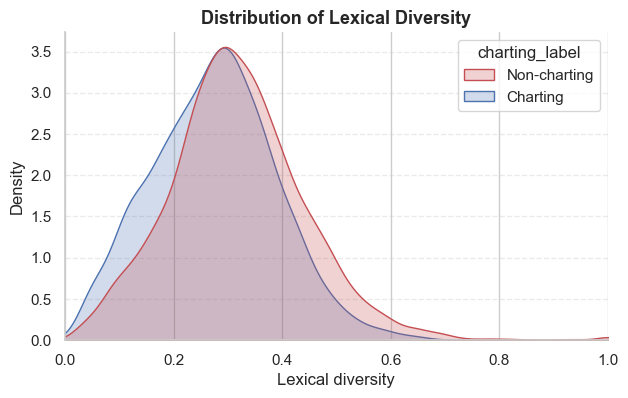

In [200]:
plt.figure(figsize=(7, 4))

sns.kdeplot(
    data=plot_data,
    x="lexical_diversity",
    hue="charting_label",
    fill=True,
    alpha=0.25,
    palette=chart_colors,
    common_norm=False
)

plt.title("Distribution of Lexical Diversity", fontsize=13, weight="bold")
plt.xlabel("Lexical diversity")
plt.ylabel("Density")
plt.xlim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.show()


### Distribution of Lexical Diversity
The density plot shows the distribution of lexical diversity for charting and non-charting songs. Both distributions are centered around similar values, with most songs falling between approximately 0.2 and 0.4.

However, the distribution for charting songs is slightly shifted to the left, indicating lower lexical diversity compared to non-charting songs. This is consistent with the earlier findings based on average values.

At the same time, there is substantial overlap between the two distributions, suggesting that lexical diversity alone does not perfectly separate charting from non-charting songs.

Overall, this provides additional support for $H1_3$, as charting songs tend to have lower lexical diversity, although the difference is moderate rather than extreme.

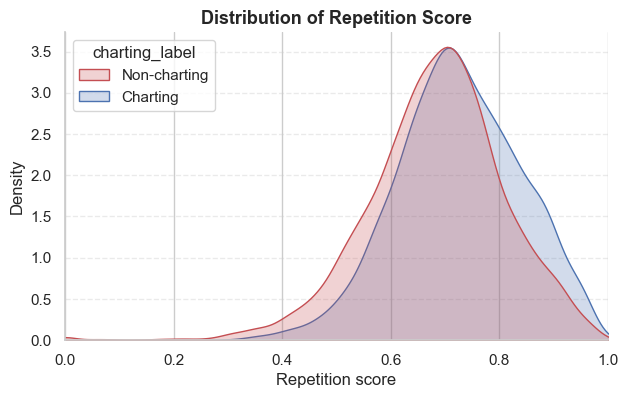

In [201]:
plt.figure(figsize=(7, 4))

sns.kdeplot(
    data=plot_data,
    x="repetition_score",
    hue="charting_label",
    fill=True,
    alpha=0.25,
    palette=chart_colors,
    common_norm=False
)

plt.title("Distribution of Repetition Score", fontsize=13, weight="bold")
plt.xlabel("Repetition score")
plt.ylabel("Density")
plt.xlim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.show()


### Distribution of Repetition Score
The density plot shows the distribution of repetition scores for charting and non-charting songs. Both distributions are centered around relatively high values, with most songs falling between approximately 0.6 and 0.8.

However, the distribution for charting songs is slightly shifted to the right, indicating higher repetition scores compared to non-charting songs. This is consistent with the earlier findings based on average values.

As with the other variables, there is substantial overlap between the two distributions, suggesting that repetition alone does not fully distinguish charting songs from non-charting songs.

Overall, this provides additional support for $H1_2$, as charting songs tend to be more repetitive, although the difference is moderate rather than extreme.

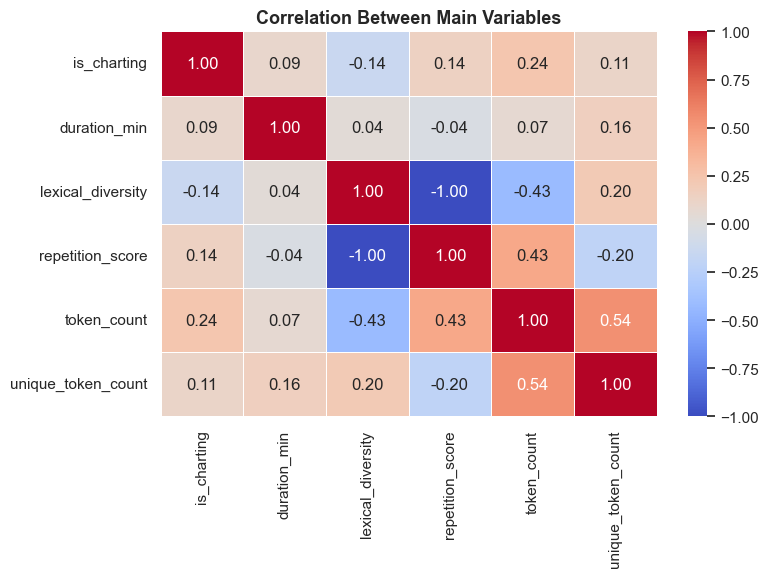

In [202]:
corr_cols = [
    "is_charting",
    "duration_min",
    "lexical_diversity",
    "repetition_score",
    "token_count",
    "unique_token_count"
]

plt.figure(figsize=(8, 5))

sns.heatmap(
    plot_data[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Main Variables", fontsize=13, weight="bold")
plt.show()

### Correlation Between Main Variables HeatMap
The correlation heatmap shows the relationships between the main variables used in the analysis. Most notably, lexical diversity and repetition score have a perfect negative correlation of -1.00. This is expected, as both variables are derived from the same underlying word frequency structure, meaning they capture the same concept from opposite perspectives.

In relation to chart success, the correlations are relatively weak. Duration shows a small positive correlation with charting (0.09), which aligns with previous findings that charting songs are slightly longer, although the effect is minimal. Lexical diversity has a weak negative correlation with charting (-0.14), while repetition score has a weak positive correlation (0.14). These results are consistent with $H1_2$ and $H1_3$, suggesting that more repetitive and less lexically diverse songs are slightly more likely to chart.

Token count shows a somewhat stronger positive correlation with charting (0.24), indicating that longer lyrics may be associated with chart success. Additionally, token count is negatively correlated with lexical diversity (-0.43) and positively correlated with repetition score (0.43), reinforcing the idea that longer songs tend to reuse words more frequently.

Overall, the correlations suggest that while lyrical simplicity is associated with chart success, the relationships are relatively weak. This implies that these features alone are not sufficient to strongly predict whether a song will chart, partially supporting $H1_4$ but also indicating that other factors likely play an important role.

In [203]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness"
]

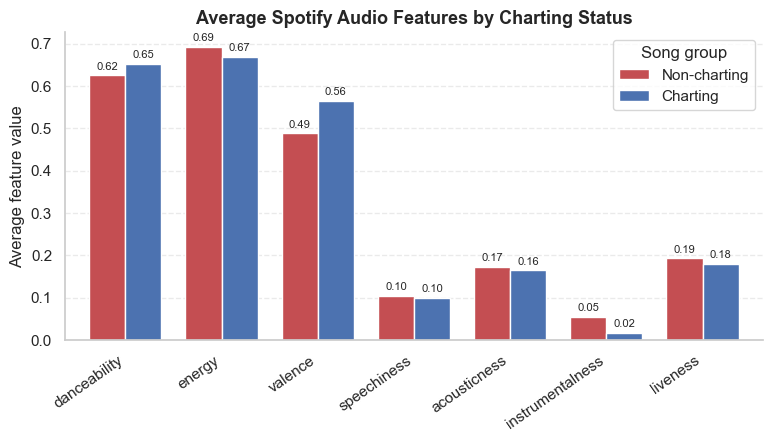

In [204]:
audio_means = plot_data.groupby("charting_label")[audio_features].mean().T
audio_means = audio_means[["Non-charting", "Charting"]]

ax = audio_means.plot(
    kind="bar",
    figsize=(9, 4),
    color=[chart_colors["Non-charting"], chart_colors["Charting"]],
    width=0.75
)

ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(ax.containers[1], fmt="%.2f", padding=3, fontsize=8)



plt.title("Average Spotify Audio Features by Charting Status", fontsize=13, weight="bold")
plt.xlabel("")
plt.ylabel("Average feature value")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Song group")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.grid(axis="x", visible=False)
sns.despine()

plt.show()

### Average Spotify Audio Features by Charting Status 
The chart compares average Spotify audio features between charting and non-charting songs. Charting songs show slightly higher danceability (0.65 vs 0.62) and valence (0.56 vs 0.49), suggesting they are generally more upbeat and suitable for wider audiences.

At the same time, charting songs have lower instrumentalness (0.02 vs 0.05), indicating a stronger focus on vocals. Differences in energy, acousticness, and liveness are relatively small.

Overall, the results suggest that charting songs tend to be more danceable, more positive in tone, and less instrumental, although the differences are moderate.

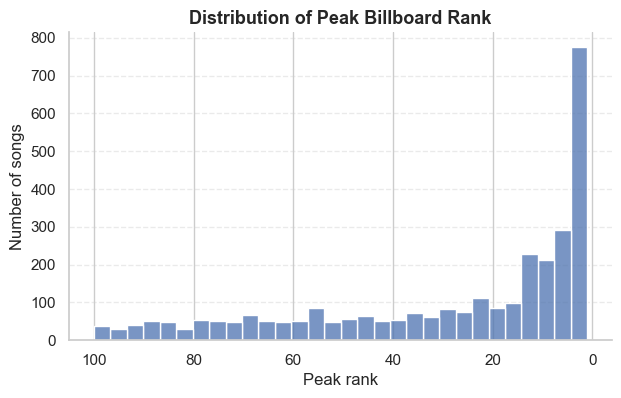

In [205]:
charting_only = plot_data[plot_data["is_charting"] == 1].copy()

plt.figure(figsize=(7, 4))

sns.histplot(
    data=charting_only,
    x="peak_rank",
    bins=30,
    color=chart_colors["Charting"],
    alpha=0.75
)

plt.title("Distribution of Peak Billboard Rank", fontsize=13, weight="bold")
plt.xlabel("Peak rank")
plt.ylabel("Number of songs")
plt.gca().invert_xaxis()

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.show()


### Distibution of Peak Billboard Rank
The histogram shows the distribution of peak Billboard ranks for charting songs. The distribution is skewed toward lower rank values, meaning that a larger number of songs reach higher chart positions (closer to rank 1).

This suggests that among charting songs, many achieve relatively strong peak positions rather than only appearing briefly at lower ranks. However, there is still a spread across the full range of ranks, indicating variation in levels of commercial success.

## Statistical Testing 

Welch’s t-test was used because the charting and non-charting groups have different sample sizes and may not have equal variance.

In [210]:
test_variables = [
    "duration_min",
    "lexical_diversity",
    "repetition_score"
]

In [211]:
charting = analysis_data[analysis_data["is_charting"] == 1]
non_charting = analysis_data[analysis_data["is_charting"] == 0]

for var in test_variables:
    t_stat, p_value = ttest_ind(
        charting[var].dropna(),
        non_charting[var].dropna(),
        equal_var=False
    )
    
    print(f"{var}")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.2e}")
    print()

duration_min
T-statistic: 11.5276
P-value: 2.15e-30

lexical_diversity
T-statistic: -17.9398
P-value: 5.83e-70

repetition_score
T-statistic: 17.9398
P-value: 5.83e-70



The Welch’s t-test results show statistically significant differences between charting and non-charting songs for all three main variables.

For duration, the p-value is below 0.05, meaning there is a significant difference in average song length. However, the direction is opposite to $H1_1$: charting songs are significantly longer, not shorter.

For lexical diversity, the result is also statistically significant. Since charting songs have lower average lexical diversity, this supports $H1_3$.

For repetition score, the result is statistically significant as well. Since charting songs have higher repetition scores, this supports $H1_2$.

Overall, the tests show that the observed differences are statistically significant. The lyrical results support the structural simplification hypothesis, while the duration result does not.

In [213]:
def cohens_d(group1, group2):
    group1 = group1.dropna()
    group2 = group2.dropna()
    
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(
        ((n1 - 1) * group1.std() ** 2 + (n2 - 1) * group2.std() ** 2) / (n1 + n2 - 2)
    )
    
    return (group1.mean() - group2.mean()) / pooled_std

for var in test_variables:
    d = cohens_d(charting[var], non_charting[var])
    print(f"{var}")
    print(f"Cohen's d: {d:.3f}")
    print()

duration_min
Cohen's d: 0.222

lexical_diversity
Cohen's d: -0.347

repetition_score
Cohen's d: 0.347



The Cohen’s d results show that the differences are statistically significant but not large in practical terms. Duration has a small effect size ($d = 0.222$), meaning charting songs are only slightly longer than non-charting songs.

Lexical diversity ($d = -0.347$) and repetition score ($d = 0.347$) also show small-to-moderate effects. This supports $H1_2$ and $H1_3$, but the effect sizes suggest that lyrical simplicity is only one factor associated with chart success, not a complete explanation.

Overall, the statistical tests strengthen the main conclusion: charting songs are significantly more repetitive and less lexically diverse, but the differences are moderate rather than extreme.

## Results and Interpretations

The results show that charting and non-charting songs differ in several measurable ways. In the prepared dataset, 3,063 songs were matched to Billboard chart records, while 10,671 songs were treated as non-charting. 
This means that the dataset is imbalanced, with charting songs making up about 22% of the observations.

The first hypothesis expected Billboard-charting songs to be shorter than non-charting songs.
The results do not support this. Charting songs had a higher average duration of 4.03 minutes, compared to 3.82 minutes for non-charting songs.
The density plot showed the same pattern, with charting songs slightly shifted toward longer durations.
Welch's t-test confirmed that this difference is statistically significant, but the direction is opposite to the hypothesis.
The effect size was small, with Cohen's d = 0.222, so duration does not appear to be a strong practical difference between the two groups.

The lyrical measures showed a clearer pattern. Charting songs had lower average lexical diversity, 0.275 compared to 0.318 for non-charting songs.
This means that charting songs used a smaller proportion of unique words in their lyrics. The distribution plot also showed that charting songs were slightly shifted toward lower lexical diversity.
Welch's t-test showed that this difference was statistically significant, and the effect size was small to moderate, with Cohen's d = -0.347. This supports the hypothesis that charting songs have lower lexical diversity.

Charting songs also had higher repetition scores, with an average of 0.725 compared to 0.682 for non-charting songs. 
This means that a larger share of the words in charting songs were repeated beyond their first occurrence.
The density plot showed the same pattern, with charting songs shifted slightly toward higher repetition. Welch's t-test confirmed that the difference was statistically significant, and Cohen's d = 0.347 suggested a small-to-moderate effect.
This supports the hypothesis that charting songs are more repetitive.

The correlation heatmap gave a similar interpretation. The correlation between chart success and duration was weak and positive, which matches the finding that charting songs were slightly longer. Lexical diversity had a weak negative correlation with charting, while repetition score had a weak positive correlation with charting.
This suggests that lyrical simplicity is associated with chart success, but the relationship is not strong enough to explain chart success by itself.

The supplementary audio-feature analysis showed that charting songs were slightly more danceable and had higher valence, while non-charting songs had higher instrumentalness.
These results are not part of the main hypotheses, but they suggest that commercially successful songs in this sample may also differ in some musical characteristics, not only in lyrical structure.

Overall, the results partially support the structural simplification idea.
The strongest support comes from the lyrical variables:
charting songs are more repetitive and less lexically diverse than non-charting songs.
However, the duration hypothesis was not supported, because charting songs were slightly longer rather than shorter.
The effect sizes also show that these differences are moderate, so structural simplicity should be understood as one factor related to chart success, not as a complete explanation of why a song becomes commercially successful.


## Limitations

This project has several limitations that should be considered when interpreting the results.

- First, the dataset is imbalanced, with a much larger number of non-charting songs compared to charting songs. Although this reflects the real-world rarity of commercial success, it may influence comparisons between the two groups.

- Second, the analysis focuses only on English-language songs with available lyrics. This excludes non-English music and songs without lyrics, which may limit the generalizability of the findings.

- Third, the measures of structural simplicity are limited to duration, repetition score, and lexical diversity. While these capture important aspects of lyrical simplicity, they do not account for other relevant features such as melody, rhythm, song structure (e.g., chorus frequency), or production quality.

- Additionally, lexical diversity and repetition score are mathematically related, meaning they should not be interpreted as fully independent measures. They reflect different perspectives on the same underlying word usage patterns.

- Another limitation is that chart success is treated as a binary variable (charting vs non-charting). This simplifies the concept of commercial success and does not capture differences in how successful songs are (e.g., peak rank, weeks on chart).

- Finally, the analysis is observational and does not imply causation. While simpler and more repetitive lyrics are associated with chart success, this does not mean that simplicity causes a song to become popular. Other factors such as artist popularity, marketing, genre, and cultural trends likely play a significant role.

Overall, these limitations suggest that the results should be interpreted as evidence of association rather than definitive proof of the role of structural simplicity in popular music.

## Conclusion

This project examined whether commercially successful songs are structurally simpler than non-charting songs. The results show that charting songs tend to have lower lexical diversity and higher repetition, supporting the idea that successful songs are lyrically simpler and more repetitive.

However, charting songs were not shorter, and the differences across all variables were small to moderate in size. This suggests that structural simplicity is associated with chart success, but it is not a strong or sufficient explanation on its own.

Overall, the findings indicate that while simpler lyrical structure may contribute to popularity, commercial success in music is likely influenced by a combination of multiple factors beyond the scope of this analysis.

## Sources

- Parada-Cabaleiro, E., et al. (2024). 
  Link: https://www.nature.com/articles/s41598-024-55742-x

- Varnum, M. E. W., et al. (2021)  
  Link: https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0244576

## 